Generation of vortices in 2d

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output
from pygpe.shared.grid import Grid
from pygpe.scalar.wavefunction import ScalarWavefunction
from pygpe.scalar.evolution import step_wavefunction

In [2]:
pts = (512, 512)
dx, dy = (0.5, 0.5)
dA = dx * dy
grid = Grid(pts, (dx, dy))

n0 = 1.0     
g = 0.5      
dt = 0.01    
cs = np.sqrt(g * n0)  
v_obs = 1.3 * cs    

V0 = 20.0  
sigma = 1.5  
x0_start = -grid.x_mesh.get().max() / 2
y0 = 0.0    

params = {'g': g, 'dt': dt, 'trap': cp.zeros(pts, dtype=cp.float64)}

X_gpu = grid.x_mesh
Y_gpu = grid.y_mesh

In [3]:
def update_trap(t):
    xt = x0_start + v_obs * t
    new_trap = V0 * cp.exp(-((X_gpu - xt)**2 + (Y_gpu - y0)**2) / (2 * sigma**2))
    return new_trap

In [4]:
kx = cp.fft.fftfreq(pts[0], d=dx) * 2 * np.pi
ky_vec = cp.fft.fftfreq(pts[1], d=dy) * 2 * np.pi
KX, KY = cp.meshgrid(kx, ky_vec, indexing='ij')
K2 = KX**2 + KY**2

In [5]:
psi_total = np.sqrt(n0) * np.ones(pts, dtype=np.complex128)

wfn = ScalarWavefunction(grid)
wfn.component = cp.asarray(psi_total)
if hasattr(wfn, 'fourier_component'):
    wfn.fourier_component = cp.fft.fftn(wfn.component)

In [6]:
wfn = ScalarWavefunction(grid)
wfn.component = cp.asarray(psi_total, dtype=cp.complex128)

if hasattr(wfn, 'fourier_component'):
    wfn.fourier_component = cp.fft.fftn(wfn.component)

params = {'g': g, 'dt': dt, 'trap': cp.zeros(pts, dtype=cp.float64)}

In [7]:
def time_energy(wfn, K2, g, dA, pts):
    psi = wfn.component
    dens = cp.abs(psi)**2
    
    n_atomi = cp.sum(dens) * dA
    
    psi_k = cp.fft.fftn(psi)
    e_kin = 0.5 * cp.sum(K2 * cp.abs(psi_k)**2) * dA / (pts[0] * pts[1])
    
    e_int = 0.5 * g * cp.sum(dens**2) * dA
    
    return float(n_atomi.get()), float((e_kin + e_int).get())

time_history = []
energy_history = []
atom_history = []

Text(0.5, 1.0, 'Phase')

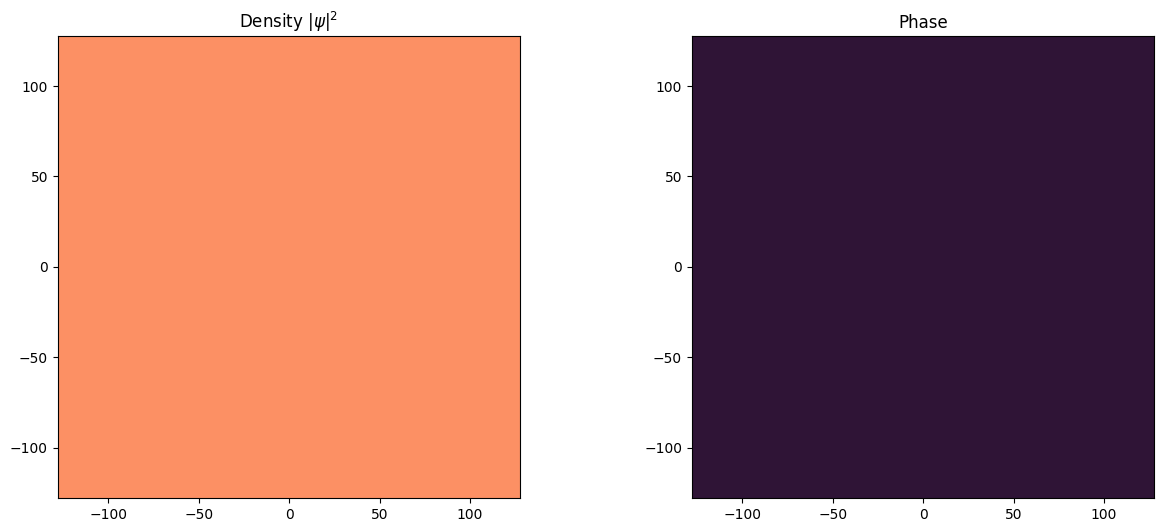

In [8]:
fig, (ax_dens, ax_phase) = plt.subplots(1, 2, figsize=(15, 6))
X_cpu, Y_cpu = grid.x_mesh.get(), grid.y_mesh.get()

im_dens = ax_dens.imshow(cp.abs(wfn.component).get()**2, 
                         extent=[X_cpu.min(), X_cpu.max(), Y_cpu.min(), Y_cpu.max()],
                         cmap='magma', origin='lower', vmin=0, vmax=1.3)
ax_dens.set_title(r"Density $|\psi|^2$")

im_phase = ax_phase.imshow(cp.angle(wfn.component).get(), 
                          extent=[X_cpu.min(), X_cpu.max(), Y_cpu.min(), Y_cpu.max()],
                          cmap='twilight', origin='lower', vmin=-np.pi, vmax=np.pi)
ax_phase.set_title("Phase")

In [9]:
steps_per_frame = 50
n_frames = 150
save_every = 10

def update(frame):
    t_start_frame = frame * steps_per_frame * dt
    
    for s in range(steps_per_frame):
        t_current = t_start_frame + s * dt
        params['trap'] = update_trap(t_current)
        
        step_wavefunction(wfn, params)

        if s % save_every == 0:
                psi = wfn.component

                current_t_global = t_start_frame + (s * dt)
                dens = cp.abs(psi)**2
           
                N = cp.sum(dens) * dA
                psi_k = cp.fft.fftn(psi)
                E_kin = 0.5 * cp.sum(K2 * cp.abs(psi_k)**2) * dA / (pts[0] * pts[1])
                E_int = 0.5 * g * cp.sum(dens**2) * dA
      
                time_history.append(current_t_global)
                atom_history.append(float(N.get()))
                energy_history.append(float((E_kin + E_int).get()))

    psi_cpu = wfn.component.get()
    im_dens.set_data(np.abs(psi_cpu)**2)
    im_phase.set_data(np.angle(psi_cpu))
    
    fig.suptitle(f"t = {(frame*steps_per_frame*dt):.2f}")
    return [im_dens, im_phase]

ani = FuncAnimation(fig, update, frames=n_frames, blit=True)

ani.save("vortices_2d_gen/v2d_gen.html", writer='html')

plt.close(fig)

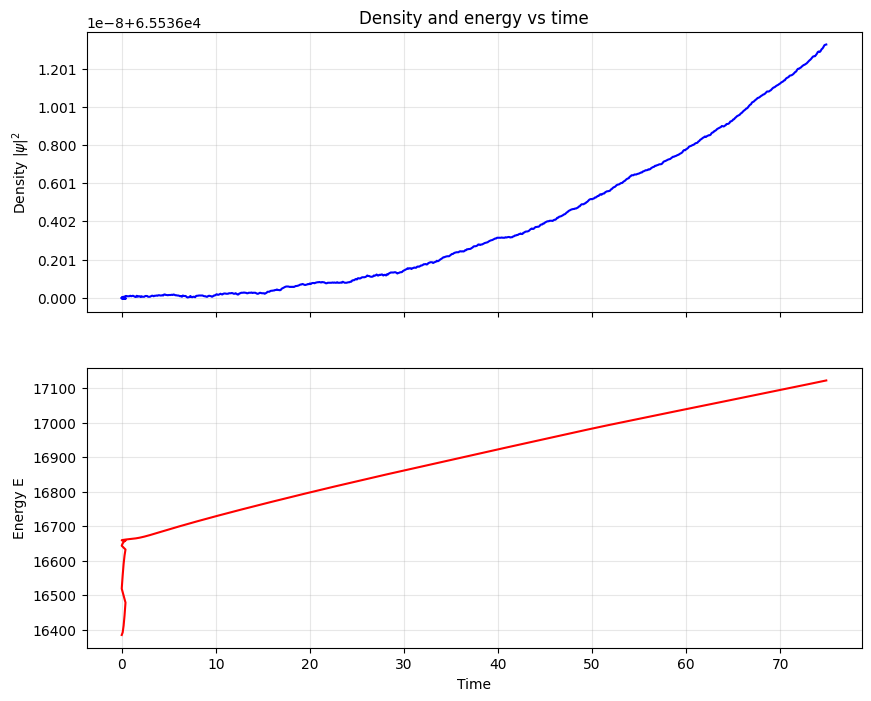

In [10]:
fig_final, (ax_at, ax_en) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax_at.plot(time_history, atom_history, color='blue', lw=1.5)
ax_at.set_title("Density and energy vs time")
ax_at.set_ylabel(r"Density $|\psi|^2$")
ax_at.grid(True, alpha=0.3)

ax_en.plot(time_history, energy_history, color='red', lw=1.5)
ax_en.set_xlabel("Time")
ax_en.set_ylabel("Energy E")
ax_en.grid(True, alpha=0.3)
plt.savefig("vortices_2d_gen/te_v2d_gen.pdf")